# Group contrast vs individual deviation -- Pancreatic Cancer (Moore et al. Batch_1)

Three acts. (1) Group -> individual: genes the matched DESeq2 run calls differential are mostly
significant in no single patient of that same group. (2) Individual -> group: the per-patient
union far exceeds the group list, and stays far above a batch-matched healthy union at the same n.
(3) What is in the excess: on a pre-specified pancreas cell-type marker panel the per-sample union
recovers more marker genes than any group contrast, and the group side reaches `padj<0.05` on none
of them across all 20 runs.

In [184]:
import json
import pickle
import sys
from collections import Counter
from pathlib import Path

import gseapy as gp
import h5py
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.calibration import bh_fdr_reject

SIG_SOURCE = 'insample'
RUVG_PICK = 'ruvg_k2'
DESIGN_PAIR = ['no_covariate', RUVG_PICK]
BATCH = 'Moore et al._Batch_1'
NEOPLASTIC = ['IPMN', 'Islet Cell Tumor', 'PDAC']
CASE_OF = {'PDAC': 'PDAC', 'IPMN': 'IPMN', 'Islet Cell Tumor': 'IsletCellTumor',
           'all neoplasm': 'PancreaticNeoplasm'}
FDR_Q = 0.05
INFLATION_Z = 1.96
DESEQ2_PADJ = 0.05
N_HC_DRAWS = 20
SEED = 0

OUT = config.GROUP_VS_INDIV_DIR / SIG_SOURCE
FIG = config.GROUP_VS_INDIV_FIG_DIR / SIG_SOURCE
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
print('source:', SIG_SOURCE, '| designs:', DESIGN_PAIR, '->', OUT)

source: insample | designs: ['no_covariate', 'ruvg_k2'] -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/GroupVsIndividual/insample


In [185]:
def load_source(src):
    if src == 'insample':
        ZD = config.ZSCORES_MIXED_DIR
        dm = pd.read_csv(ZD / 'sample_meta.csv')
        hm = pd.read_csv(ZD / 'hc_meta.csv')
        dk = dm['ood_keep'].values.astype(bool)
        hk = (hm['batch'] == BATCH).values
        return dict(genes=np.array(pickle.load(open(ZD / 'gene_names.pkl', 'rb'))),
                    Z_dis=np.load(ZD / 'Z_disease_shash.npy')[dk], dis=dm.loc[dk, 'sample'].values,
                    Z_hc=np.load(ZD / 'Z_hc_shash.npy')[hk], hc=hm.loc[hk, 'sample'].values)
    LD = config.LOBO_MIXED_DIR / BATCH.replace(' ', '_')
    info = json.load(open(LD / 'meta.json'))
    Z = np.load(LD / 'Z_test_shash.npy')
    names = np.array(info['test_names'])
    is_hc = np.array(info['test_is_hc'], dtype=bool)
    keep = np.load(LD / 'ood_mask.npy').astype(bool)
    return dict(genes=np.array(pickle.load(open(LD / 'gene_names.pkl', 'rb'))),
                Z_dis=Z[keep & ~is_hc], dis=names[keep & ~is_hc],
                Z_hc=Z[keep & is_hc], hc=names[keep & is_hc])


src = load_source(SIG_SOURCE)
genes = src['genes']

with h5py.File(config.H5AD_PATH, 'r') as h:
    dec = lambda a: np.array([x.decode('utf-8', 'replace') if isinstance(x, bytes) else str(x) for x in a])
    g = h['obs/Stage/Condition']
    stage_all = pd.Series(pd.Categorical.from_codes(g['codes'][()], dec(g['categories'][()])).astype(str),
                          index=dec(h['obs/_index'][()]))

dis_stage = pd.Series(src['dis']).map(stage_all).values
neo = np.isin(dis_stage, NEOPLASTIC)
Z_neo, names_neo, stage_neo = src['Z_dis'][neo], src['dis'][neo], dis_stage[neo]
print(f"genes={len(genes)}  neoplasm={neo.sum()}  HC(batch-matched)={len(src['hc'])}")
print(pd.Series(stage_neo).value_counts().to_string())

genes=19858  neoplasm=72  HC(batch-matched)=71
PDAC                37
IPMN                27
Islet Cell Tumor     8


In [186]:
def bh_sig_matrix(Z, q=FDR_Q):
    return np.vstack([bh_fdr_reject(2 * norm.sf(np.abs(Z[i])), q=q) for i in range(Z.shape[0])])

def inflation_keep(Z, thr=INFLATION_Z):
    f = (np.abs(Z) > thr).mean(axis=1)
    q1, q3 = np.percentile(f, [25, 75])
    return f <= q3 + 1.5 * (q3 - q1)


dis_ok, hc_ok = inflation_keep(Z_neo), inflation_keep(src['Z_hc'])
print(f'inflation QC: patients {dis_ok.sum()}/{len(dis_ok)} kept, HC {hc_ok.sum()}/{len(hc_ok)} kept')
Z_neo, names_neo, stage_neo = Z_neo[dis_ok], names_neo[dis_ok], stage_neo[dis_ok]
Z_hc_qc = src['Z_hc'][hc_ok]

SIG = bh_sig_matrix(Z_neo)
SIG_HC = bh_sig_matrix(Z_hc_qc)
per_sample = pd.DataFrame(dict(sample=names_neo, stage=stage_neo, n_sig=SIG.sum(axis=1)))
per_sample.to_csv(OUT / 'per_sample_nsig.csv', index=False)

if SIG_SOURCE == 'insample':
    ref = pd.read_csv(config.ZSCORES_MIXED_DIR / 'sample_bh_sig.csv').set_index('sample')['n_sig']
    chk = per_sample.assign(pipeline=per_sample['sample'].map(ref))
    print(f"BH vs pipeline sample_bh_sig.csv: exact={int((chk.n_sig == chk.pipeline).sum())}/{len(chk)}")

print(per_sample.groupby('stage')['n_sig'].agg(n='size', median='median', mean='mean').round(1).to_string())
print(f"HC median n_sig = {np.median(SIG_HC.sum(axis=1)):.0f}, "
      f"mean = {SIG_HC.sum(axis=1).mean():.1f}")

inflation QC: patients 72/72 kept, HC 70/71 kept
BH vs pipeline sample_bh_sig.csv: exact=72/72
                   n  median  mean
stage                             
IPMN              27    18.0  37.1
Islet Cell Tumor   8    24.0  34.2
PDAC              37    42.0  90.3
HC median n_sig = 1, mean = 4.5


In [187]:
gene_set = set(genes)
deg, padj_of = {}, {}
for f in sorted(config.PANCREATIC_DEG_DIR.glob('moore_b1__*/*.csv.gz')):
    case = f.parent.name.split('__')[1]
    design = f.name.split('.')[0]
    r = pd.read_csv(f, index_col=0)
    deg[(case, design)] = set(r.index[r['padj'].fillna(1.0) < DESEQ2_PADJ]) & gene_set
    padj_of[(case, design)] = r[['padj', 'pvalue', 'log2FoldChange']]

deg_summary = (pd.DataFrame([dict(case=c, design=d, n_sig=len(v)) for (c, d), v in deg.items()])
               .pivot(index='case', columns='design', values='n_sig'))
deg_summary.to_csv(OUT / 'deseq2_nsig_by_case_design.csv')
print(deg_summary.to_string())
print(f'\n{len(deg)} group runs loaded (5 case definitions x 4 designs)')
print('all-run union (reference only, includes Pancreatitis contrasts):',
      len(set().union(*deg.values())))

design              no_covariate  ruvg_k1  ruvg_k2  ruvg_k3
case                                                       
IPMN                           0       54      113      125
IsletCellTumor                38      140      201      268
PDAC                          95      172      264      249
PancreaticNeoplasm            20      113      148      127
Pancreatitis                   0       44       76       80

20 group runs loaded (5 case definitions x 4 designs)
all-run union (reference only, includes Pancreatitis contrasts): 1112


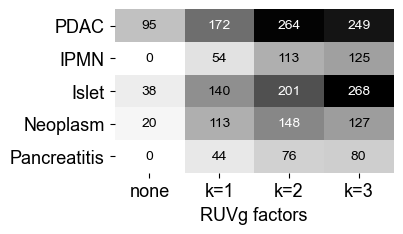

In [188]:
ORDER = ['PDAC', 'IPMN', 'IsletCellTumor', 'PancreaticNeoplasm', 'Pancreatitis']
DESIGN_ORDER = ['no_covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3']
t = deg_summary.loc[ORDER, DESIGN_ORDER]

fig, ax = plt.subplots(figsize=(3.6, 2.12))
ax.imshow(t.values, cmap='Greys', vmin=0, vmax=t.values.max(), aspect='auto')
for i in range(t.shape[0]):
    for j in range(t.shape[1]):
        v = t.values[i, j]
        ax.text(j, i, v, ha='center', va='center',
                color='white' if v > t.values.max() * 0.55 else 'black')
ax.set_xticks(range(4), ['none', 'k=1', 'k=2', 'k=3'])
ax.set_yticks(range(5), ['PDAC', 'IPMN', 'Islet', 'Neoplasm', 'Pancreatitis'])
ax.set_xlabel('RUVg factors')
for s in ax.spines.values():
    s.set_visible(False)
fig.savefig(FIG / 'fig_group_run_grid.png', dpi=300, bbox_inches='tight')

## Act 1 -- the group list describes nobody

`deg_orphan`: genes at `padj<0.05` in the matched run that are BH-significant in not one patient
that run was built from. `abs_mean_over_sd` / `sign_concordance` ask the same on a continuous
scale over the group's own DE genes.

In [189]:
rng = np.random.default_rng(SEED)
n_hc = SIG_HC.shape[0]


def group_mask(grp):
    return np.ones(len(names_neo), bool) if grp == 'all neoplasm' else (stage_neo == grp)

def hc_union_draws(n, cols=None):
    ns = min(n, n_hc)
    M = SIG_HC if cols is None else SIG_HC[:, cols]
    return ns, np.array([int(M[rng.choice(n_hc, ns, replace=False)].any(axis=0).sum())
                         for _ in range(N_HC_DRAWS)])

rows = []
for design in DESIGN_PAIR:
    for grp, case in CASE_OF.items():
        m = group_mask(grp)
        nmu = set(genes[SIG[m].any(axis=0)])
        D = deg[(case, design)]
        ns, draws = hc_union_draws(int(m.sum()))
        hcu = int(np.median(draws))
        rows.append(dict(design=design, group=grp, n_pat=int(m.sum()), n_hc_drawn=ns,
                         deg_n=len(D), nm_union=len(nmu), hc_union=hcu,
                         nm_over_hc=round(len(nmu) / max(hcu, 1), 2),
                         shared=len(nmu & D), novel=len(nmu - D),
                         deg_orphan=len(D - nmu),
                         deg_orphan_frac=round(len(D - nmu) / max(len(D), 1), 3)))
matched = pd.DataFrame(rows)
matched.to_csv(OUT / 'matched_group_vs_individual.csv', index=False)
print(matched.to_string(index=False))
print('\nn_pat / n_hc_drawn are SAMPLE counts; deg_n / nm_union / hc_union are GENE counts.')
print('the comparison is nm_union vs hc_union at n_pat vs n_hc_drawn samples.')

      design            group  n_pat  n_hc_drawn  deg_n  nm_union  hc_union  nm_over_hc  shared  novel  deg_orphan  deg_orphan_frac
no_covariate             PDAC     37          37     95      2769       121       22.88      17   2752          78            0.821
no_covariate             IPMN     27          27      0       935       103        9.08       0    935           0            0.000
no_covariate Islet Cell Tumor      8           8     38       263        33        7.97       0    263          38            1.000
no_covariate     all neoplasm     72          70     20      3567       310       11.51      19   3548           1            0.050
     ruvg_k2             PDAC     37          37    264      2769       132       20.98      96   2673         168            0.636
     ruvg_k2             IPMN     27          27    113       935        97        9.64       6    929         107            0.947
     ruvg_k2 Islet Cell Tumor      8           8    201       263        28 

In [190]:
gpos = {g: i for i, g in enumerate(genes)}
carriers = SIG.sum(axis=0)
hc_carriers = SIG_HC.sum(axis=0)
pd.DataFrame(dict(gene=genes, n_patients_sig=carriers, n_hc_sig=hc_carriers)).to_csv(
    OUT / 'gene_carrier_table.csv', index=False)

leg1b = []
for design in DESIGN_PAIR:
    D = sorted(deg[('PancreaticNeoplasm', design)] | deg[('PDAC', design)])
    idx = np.array([gpos[g] for g in D])
    Zu = Z_neo[:, idx]
    mean_z, sd_z = Zu.mean(axis=0), Zu.std(axis=0, ddof=1)
    leg1b.append(pd.DataFrame(dict(design=design, gene=D, mean_z=mean_z, sd_z=sd_z,
                                   abs_mean_over_sd=np.abs(mean_z) / sd_z,
                                   sign_concordance=np.mean(np.sign(Zu) == np.sign(mean_z)[None, :], axis=0),
                                   n_patients_sig=carriers[idx])))
leg1b = pd.concat(leg1b, ignore_index=True)
leg1b.to_csv(OUT / 'mean_representativeness.csv', index=False)

print('representativeness of the group mean over its own DE genes (PDAC + pooled contrast)')
print(leg1b.groupby('design')[['abs_mean_over_sd', 'sign_concordance']]
      .describe(percentiles=[0.5]).round(3).to_string())
for d, sub in leg1b.groupby('design'):
    print(f"  {d}: |mean|/SD < 0.5 in {(sub.abs_mean_over_sd < 0.5).mean():.0%}, "
          f"sign concordance < 0.7 in {(sub.sign_concordance < 0.7).mean():.0%}")

representativeness of the group mean over its own DE genes (PDAC + pooled contrast)
             abs_mean_over_sd                                    sign_concordance                                   
                        count   mean    std    min    50%    max            count   mean    std    min    50%    max
design                                                                                                              
no_covariate            113.0  0.471  0.382  0.011  0.361  1.973            113.0  0.663  0.130  0.444  0.639  0.986
ruvg_k2                 350.0  0.290  0.294  0.001  0.197  1.973            350.0  0.599  0.107  0.417  0.569  0.986
  no_covariate: |mean|/SD < 0.5 in 65%, sign concordance < 0.7 in 70%
  ruvg_k2: |mean|/SD < 0.5 in 84%, sign concordance < 0.7 in 86%


median patients on the group side: 0.57 = 41/72 agree, 31 opposite

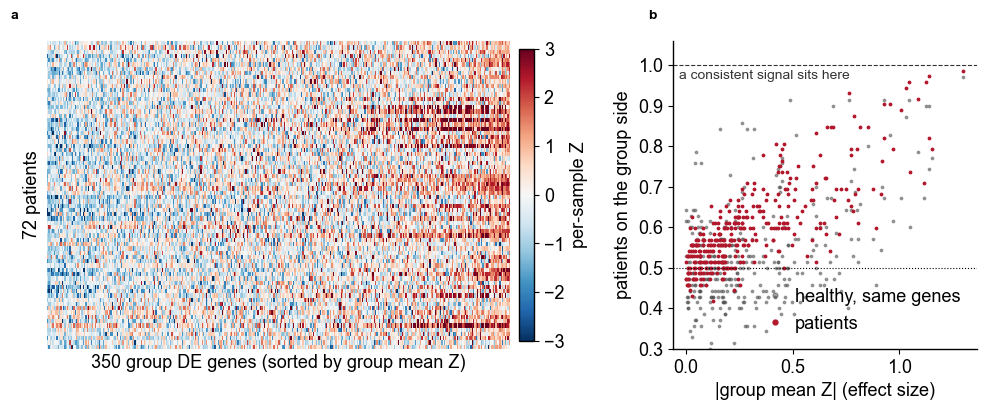

In [191]:
# Direction, not magnitude: over the group's own DE genes, is each patient on the side the
# group mean claims? Healthy samples on the same genes give the 0.5 reference.
C_POS, C_HC = '#B2182B', '#4D4D4D'
DSG = RUVG_PICK
D = sorted(deg[('PancreaticNeoplasm', DSG)] | deg[('PDAC', DSG)])
idx = np.array([gpos[g] for g in D])
Zu, Zh = Z_neo[:, idx], Z_hc_qc[:, idx]
mz = Zu.mean(axis=0)
o = np.argsort(mz)
agree_pat = (np.sign(Zu) == np.sign(mz)[None, :]).mean(axis=0)
agree_hc = (np.sign(Zh) == np.sign(mz)[None, :]).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                         gridspec_kw=dict(width_ratios=[1.6, 1.0], wspace=0.35))
for a in axes:
    a.tick_params()

ax = axes[0]
im = ax.imshow(Zu[:, o], cmap='RdBu_r', vmin=-3, vmax=3, aspect='auto', interpolation='nearest')
ax.set_xlabel(f'{len(D)} group DE genes (sorted by group mean Z)')
ax.set_ylabel(f'{Zu.shape[0]} patients')
ax.set_xticks([])
ax.set_yticks([])
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('per-sample Z')
cb.ax.tick_params()
for s in ax.spines.values():
    s.set_visible(False)

ax = axes[1]
ax.plot(np.abs(mz), agree_hc, '.', ms=3.5, color=C_HC, alpha=0.5, label='healthy, same genes')
ax.plot(np.abs(mz), agree_pat, '.', ms=3.5, color=C_POS, label='patients')
ax.axhline(0.5, color='k', lw=0.8, ls=':')
ax.axhline(1.0, color='#333333', lw=0.8, ls='--')
ax.text(0.02, 0.965, 'a consistent signal sits here', color='#333333',
        transform=ax.get_yaxis_transform())
ax.set_ylim(0.3, 1.06)
ax.set_xlabel('|group mean Z| (effect size)')
ax.set_ylabel('patients on the group side')
ax.legend(frameon=False, loc='lower right', handletextpad=0.1, markerscale=2)
med = np.median(agree_pat)
n_pat = Zu.shape[0]
print(f'median patients on the group side: {med:.2f} '
      f'= {round(med * n_pat)}/{n_pat} agree, {n_pat - round(med * n_pat)} opposite')

for ax, l in zip(axes, 'ab'):
    ax.text(-0.08, 1.10, l, transform=ax.transAxes, fontweight='bold', va='top')
fig.savefig(FIG / 'fig_group_direction.png', dpi=300, bbox_inches='tight')

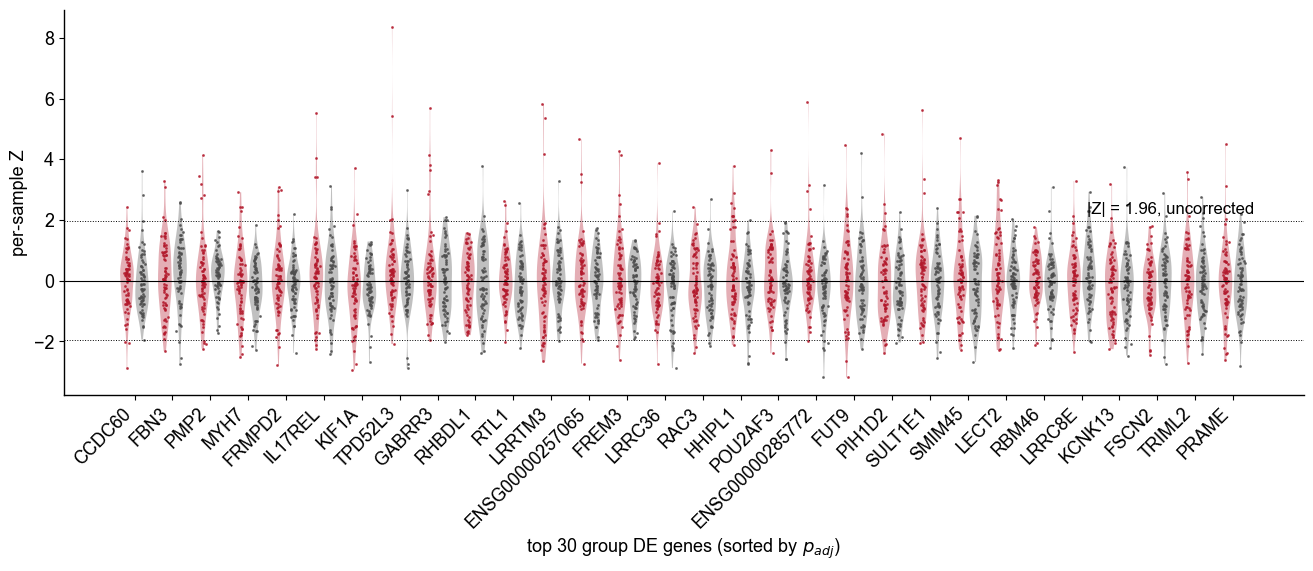

In [211]:
N_SHOW = 30
DSG = RUVG_PICK
D = sorted(deg[('PancreaticNeoplasm', DSG)] | deg[('PDAC', DSG)])
pa = padj_of[('PancreaticNeoplasm', DSG)]['padj'].combine_first(padj_of[('PDAC', DSG)]['padj'])
top = list(pa.reindex(D).sort_values().index[:N_SHOW])

with h5py.File(config.H5AD_PATH, 'r') as h:
    gn = h['var/GeneName']
    sym_all = pd.Categorical.from_codes(gn['codes'][()], dec(gn['categories'][()])).astype(str)
    sym_of = pd.Series(sym_all, index=dec(h['var/_index'][()]))
sym = [sym_of.get(g, g.split('.')[0]) for g in top]

ti = np.array([gpos[g] for g in top])
Zp, Zh = Z_neo[:, ti], Z_hc_qc[:, ti]
C_PAT, C_HC = '#B2182B', '#4D4D4D'

fig, ax = plt.subplots(figsize=(16.0, 5.0))
for k in range(N_SHOW):
    for arr, off, col in [(Zp[:, k], -0.2, C_PAT), (Zh[:, k], 0.2, C_HC)]:
        v = ax.violinplot(arr, positions=[k + off], widths=0.36, showextrema=False)
        v['bodies'][0].set_facecolor(col)
        v['bodies'][0].set_alpha(0.35)
        ax.plot(k + off + np.random.default_rng(SEED + k).normal(0, 0.035, len(arr)), arr,
                '.', ms=2.2, color=col, alpha=0.7)
ax.axhline(0, color='k', lw=0.8)
for y in (-1.96, 1.96):
    ax.axhline(y, color='k', lw=0.7, ls=':')
ax.text(N_SHOW - 0.45, 2.1, '|Z| = 1.96, uncorrected', va='bottom', ha='right', fontsize=12)
ax.set_xticks(range(N_SHOW), sym, rotation=45, ha='right')
ax.set_xlabel(f'top {N_SHOW} group DE genes (sorted by $p_{{adj}}$)')
ax.tick_params(axis='y')
ax.set_ylabel('per-sample Z')
fig.savefig(FIG / 'fig_group_top_degs_violin.png', dpi=300, bbox_inches='tight')


PDAC: mean pairwise Jaccard patients 5.85e-03, healthy 0.00e+00, independence expectation 1.36e-03; pairs with any overlap patients 38%, healthy 0%
IPMN: mean pairwise Jaccard patients 2.93e-03, healthy 1.36e-04, independence expectation 6.00e-04; pairs with any overlap patients 15%, healthy 0%
Islet Cell Tumor: mean pairwise Jaccard patients 5.78e-03, healthy 0.00e+00, independence expectation 6.28e-04; pairs with any overlap patients 29%, healthy 0%
all neoplasm: mean pairwise Jaccard patients 4.06e-03, healthy 2.27e-05, independence expectation 9.40e-04; pairs with any overlap patients 25%, healthy 0%
           group  n_pat  group_deg_k2  nm_union  shared_k2  union_of_4_designs  hc_draw_mean  hc_draw_sd
            PDAC     37           264      2769         96                 248         172.8        55.0
            IPMN     27           113       935          6                 195         116.9        53.7
Islet Cell Tumor      8           201       263          3               

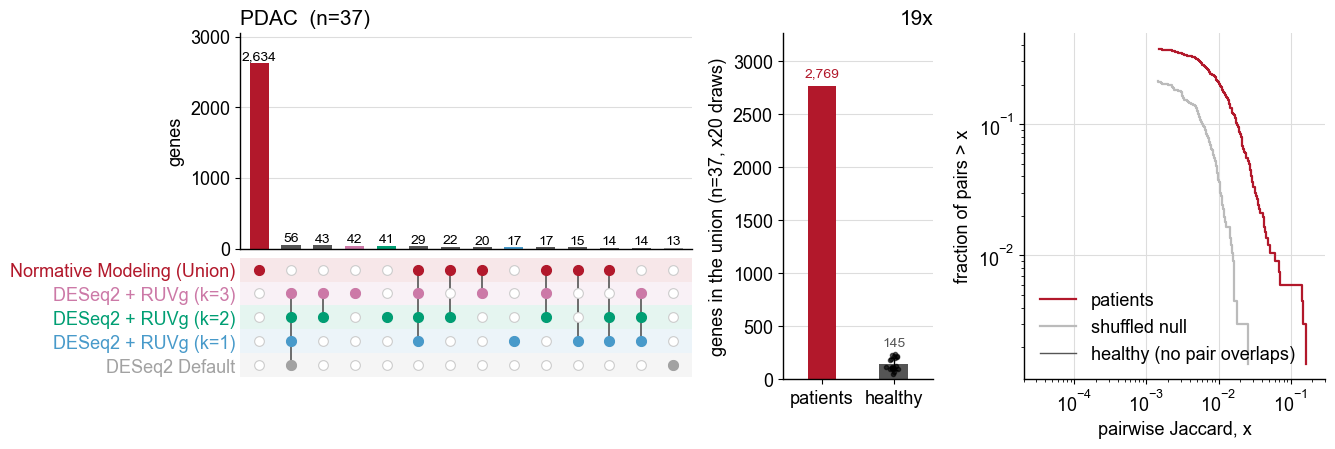

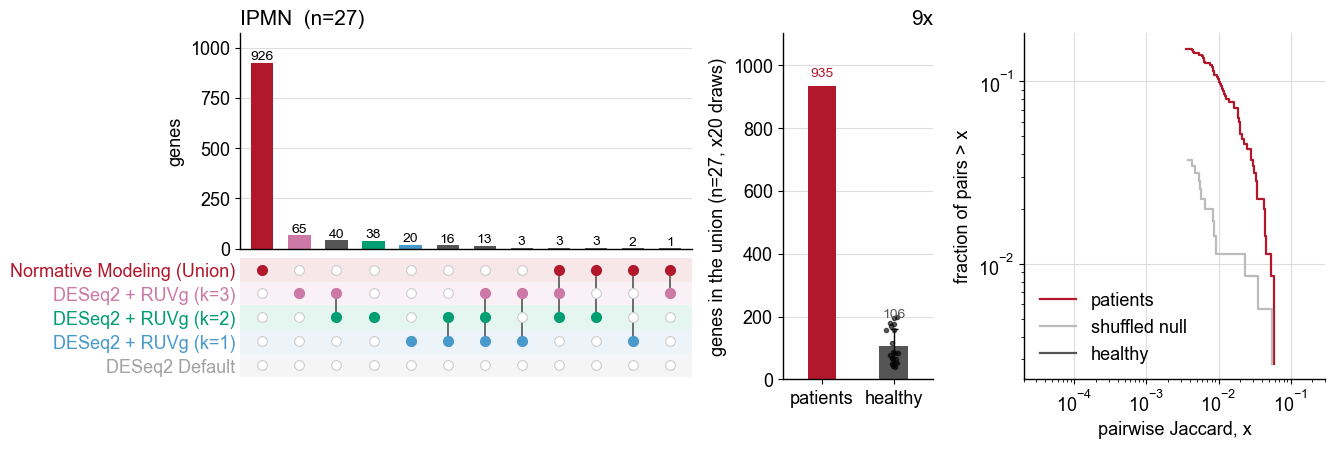

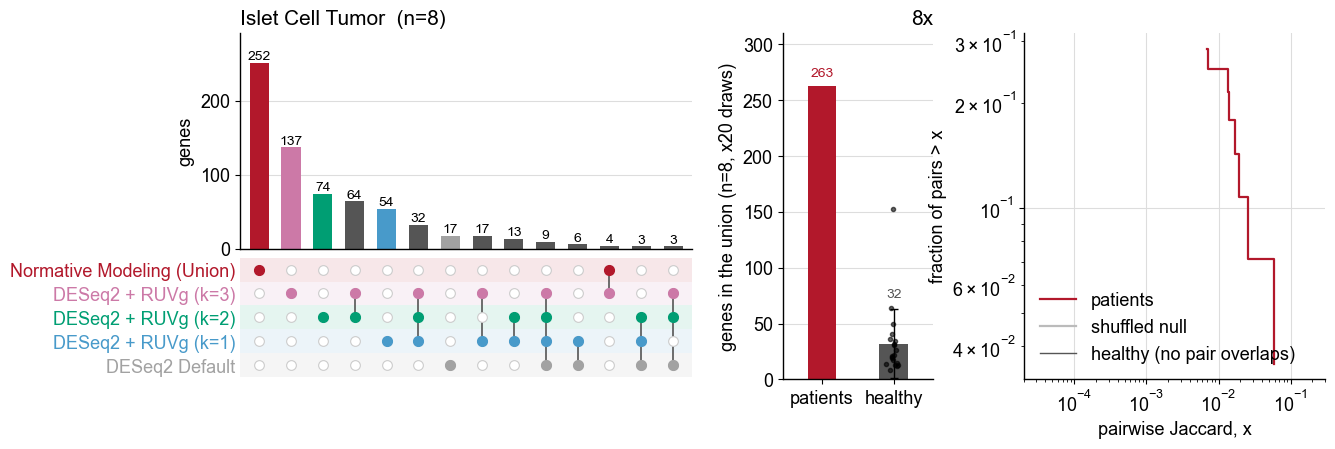

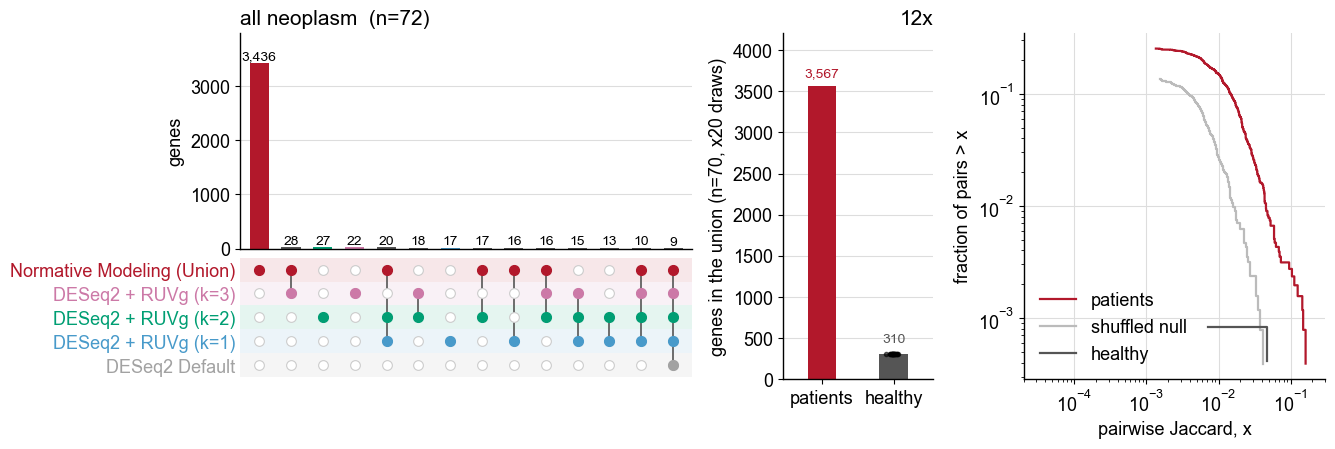

In [192]:
# More than two sets, so the UpSet idiom: bars are exclusive intersections, dots say which sets.
# Sets are the four group runs (the analyst's choice) plus the per-patient union.
UPSET_TOP = 14
VGROUPS = ['PDAC', 'IPMN', 'Islet Cell Tumor', 'all neoplasm']
UP_DESIGNS = ['no_covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3']
DESIGN_LABEL = {'no_covariate': 'DESeq2 Default', 'ruvg_k1': 'DESeq2 + RUVg (k=1)',
                'ruvg_k2': 'DESeq2 + RUVg (k=2)', 'ruvg_k3': 'DESeq2 + RUVg (k=3)'}
SET_COLOR = {'DESeq2 Default': '#A2A2A2', 'DESeq2 + RUVg (k=1)': '#489ACA',
             'DESeq2 + RUVg (k=2)': '#009E73', 'DESeq2 + RUVg (k=3)': '#CC79A7',
             'Normative Modeling (Union)': '#B2182B'}


def upset(ax_bar, ax_dot, sets, top=UPSET_TOP, ax_set=None):
    names = list(sets)
    cols = [SET_COLOR[n] for n in names]
    memb = {}
    for i, n in enumerate(names):
        for g in sets[n]:
            memb[g] = memb.get(g, 0) | (1 << i)
    combos = [c for c in Counter(memb.values()).most_common() if c[0]][:top]
    x = np.arange(len(combos))

    bar_col = [cols[int(np.log2(m))] if m and not m & (m - 1) else '#555555' for m, _ in combos]
    ax_bar.bar(x, [c[1] for c in combos], color=bar_col, width=0.6)
    for xi, (_, v) in zip(x, combos):
        ax_bar.text(xi, v, f'{v:,}', ha='center', va='bottom')
    ax_bar.set_ylabel('genes')
    ax_bar.set_xlim(-0.6, len(combos) - 0.4)
    ax_bar.set_xticks([])
    ax_bar.set_ylim(0, max(v for _, v in combos) * 1.16)
    ax_bar.set_axisbelow(True)
    ax_bar.grid(axis='y', color='#DDDDDD', lw=0.8)

    for yi in range(len(names)):
        ax_dot.axhspan(yi - 0.5, yi + 0.5, color=cols[yi], alpha=0.10, lw=0)
    for xi, (mask, _) in zip(x, combos):
        on = [i for i in range(len(names)) if mask >> i & 1]
        ax_dot.plot([xi] * len(names), range(len(names)), 'o', ms=7,
                    mfc='white', mec='#CCCCCC', mew=0.8)
        if len(on) > 1:
            ax_dot.plot([xi, xi], [min(on), max(on)], '-', lw=1.2, color='#555555', zorder=1)
        for i in on:
            ax_dot.plot([xi], [i], 'o', ms=7, mfc=cols[i], mec=cols[i], zorder=2)
    ax_dot.set_xlim(-0.6, len(combos) - 0.4)
    ax_dot.set_ylim(-0.6, len(names) - 0.4)
    ax_dot.set_yticks(range(len(names)), names)
    ax_dot.tick_params(axis='y', length=0)
    for t, c in zip(ax_dot.get_yticklabels(), cols):
        t.set_color(c)
    ax_dot.set_xticks([])
    for sp in ax_dot.spines.values():
        sp.set_visible(False)

    if ax_set is None:
        return
    ax_set.barh(range(len(names)), [len(sets[n]) for n in names], color=cols, height=0.5)
    ax_set.set_ylim(-0.6, len(names) - 0.4)
    ax_set.invert_xaxis()
    ax_set.set_yticks(range(len(names)), ['' for _ in names])
    ax_set.set_xticks([max(len(sets[n]) for n in names)])
    ax_set.set_xlabel('set size', labelpad=1)
    ax_set.set_axisbelow(True)
    ax_set.grid(axis='x', color='#DDDDDD', lw=0.8)


rows = []
for grp in VGROUPS:
    m = group_mask(grp)
    sets = {DESIGN_LABEL[d]: deg[(CASE_OF[grp], d)] for d in UP_DESIGNS}
    sets['Normative Modeling (Union)'] = set(genes[SIG[m].any(axis=0)])

    fig = plt.figure(figsize=(14, 4.5))
    gs = fig.add_gridspec(2, 3, height_ratios=[2.0, 1.15], width_ratios=[3, 1, 2],
                          hspace=0.04, wspace=0.3)
    ax_bar = fig.add_subplot(gs[0, 0])
    ax_dot = fig.add_subplot(gs[1, 0], sharex=ax_bar)
    upset(ax_bar, ax_dot, sets)

    # "isn't the union just noise?" -- the same union built from batch-matched healthy samples
    # at the same n, over N_HC_DRAWS draws.
    ns, draws = hc_union_draws(int(m.sum()))
    ax_hc = fig.add_subplot(gs[:, 1])
    nm_n = len(sets['Normative Modeling (Union)'])
    ax_hc.bar([0], [nm_n], 0.8, color='#B2182B')
    ax_hc.bar([2.0], [draws.mean()], 0.8, yerr=[draws.std()], color='#555555',
              error_kw=dict(lw=1.0, capsize=3))
    ax_hc.plot(2.0 + np.random.default_rng(SEED).normal(0, 0.09, len(draws)), draws, '.',
               color='k', alpha=0.6)
    ax_hc.text(0, nm_n * 1.02, f'{nm_n:,}', ha='center', va='bottom', color='#B2182B')
    ax_hc.text(2.0, draws.mean() + draws.std() + nm_n * 0.03,
               f'{draws.mean():.0f}', ha='center', va='bottom', color='#555555')
    ax_hc.set_xticks([0, 2.0], ['patients', 'healthy'])
    ax_hc.set_xlim(-1.1, 3.1)
    ax_hc.set_ylabel(f'genes in the union (n={ns}, x{N_HC_DRAWS} draws)')
    ax_hc.set_ylim(0, nm_n * 1.18)
    ax_hc.set_title(f'{nm_n / max(draws.mean(), 1):.0f}x', loc='right')
    ax_hc.set_axisbelow(True)
    ax_hc.grid(axis='y', color='#DDDDDD', lw=0.8)
    # and are those extra genes the same ones? mean pairwise Jaccard, patients vs healthy,
    # against the independence expectation at the same per-sample set sizes.
    P = SIG[m]
    H = SIG_HC[rng.choice(n_hc, min(int(m.sum()), n_hc), replace=False)]
    def pair_jac(M):
        k = M.sum(axis=1).astype(float)
        inter = M.astype(float) @ M.T
        u = k[:, None] + k[None, :] - inter
        iu = np.triu_indices(len(M), 1)
        return np.divide(inter[iu], u[iu], out=np.zeros(len(iu[0])), where=u[iu] > 0)
    def null_jac(M):
        k = M.sum(axis=1).astype(float)
        iu = np.triu_indices(len(M), 1)
        e = k[iu[0]] * k[iu[1]] / M.shape[1]
        return float(np.mean(e / (k[iu[0]] + k[iu[1]] - e)))
    jp, jh = pair_jac(P), pair_jac(H)
    jac = [float(jp.mean()), null_jac(P), float(jh.mean())]
    ax_j = fig.add_subplot(gs[:, 2])
    J_FLOOR = 1e-5

    def perm_pairs(M, seed=SEED):
        r = np.random.default_rng(seed)
        R = np.zeros_like(M)
        for i, k in enumerate(M.sum(axis=1)):
            R[i, r.choice(M.shape[1], int(k), replace=False)] = True
        return pair_jac(R)

    for v, c, lab in [(jp, '#B2182B', 'patients'), (perm_pairs(P), '#BBBBBB', 'shuffled null'),
                      (jh, '#555555', 'healthy')]:
        x = np.sort(v[v > 0])
        if not len(x):
            ax_j.plot([], [], color=c, label=f'{lab} (no pair overlaps)')
            continue
        y = np.arange(len(x), 0, -1) / len(v)
        ax_j.step(x, y, where='post', color=c, lw=1.6, label=lab)
    ax_j.set_xscale('log')
    ax_j.set_yscale('log')
    ax_j.set_xlim(J_FLOOR * 2, 3e-1)
    ax_j.set_xlabel('pairwise Jaccard, x')
    ax_j.set_ylabel('fraction of pairs > x')
    ax_j.legend(frameon=False, loc='lower left')
    ax_j.set_axisbelow(True)
    ax_j.grid(color='#DDDDDD', lw=0.8)
    print(f'{grp}: mean pairwise Jaccard patients {jac[0]:.2e}, healthy {jac[2]:.2e}, '
          f'independence expectation {jac[1]:.2e}; pairs with any overlap '
          f'patients {(jp > 0).mean():.0%}, healthy {(jh > 0).mean():.0%}')
    ax_bar.set_title(f'{grp}  (n={int(m.sum())})', loc='left')
    fig.savefig(FIG / f"fig_upset_{grp.replace(' ', '_')}.png", dpi=300, bbox_inches='tight')

    nmu = sets['Normative Modeling (Union)']
    Dset = deg[(CASE_OF[grp], RUVG_PICK)]
    ns, draws = hc_union_draws(int(m.sum()))
    rows.append(dict(group=grp, n_pat=int(m.sum()), group_deg_k2=len(Dset), nm_union=len(nmu),
                     shared_k2=len(Dset & nmu), union_of_4_designs=len(set().union(*sets.values()) - nmu),
                     hc_draw_mean=round(draws.mean(), 1), hc_draw_sd=round(draws.std(), 1)))
summary = pd.DataFrame(rows)
summary.to_csv(OUT / 'upset_group_vs_individual.csv', index=False)
print(summary.to_string(index=False))

In [193]:
def pair_jaccard(M, max_pairs=4000, seed=SEED):
    r = np.random.default_rng(seed)
    n = M.shape[0]
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    if len(pairs) > max_pairs:
        pairs = [pairs[k] for k in r.choice(len(pairs), max_pairs, replace=False)]
    out = []
    for i, j in pairs:
        u = int((M[i] | M[j]).sum())
        if u:
            out.append(int((M[i] & M[j]).sum()) / u)
    return np.array(out)


def size_matched_null(M, seed=SEED):
    r = np.random.default_rng(seed)
    N = M.shape[1]
    Mn = np.zeros_like(M)
    for i, k in enumerate(M.sum(axis=1)):
        if k:
            Mn[i, r.choice(N, int(k), replace=False)] = True
    return Mn


j_pat = pair_jaccard(SIG)
j_hc = pair_jaccard(SIG_HC)
j_null = pair_jaccard(size_matched_null(SIG))
spec = pd.DataFrame([dict(set_='patients', n_pairs=len(j_pat), median=np.median(j_pat), mean=j_pat.mean()),
                     dict(set_='HC (batch-matched)', n_pairs=len(j_hc), median=np.median(j_hc), mean=j_hc.mean()),
                     dict(set_='size-matched null', n_pairs=len(j_null), median=np.median(j_null), mean=j_null.mean())])
spec.to_csv(OUT / 'patient_specificity_jaccard.csv', index=False)
print(spec.round(4).to_string(index=False))

share = pd.Series(carriers[carriers > 0]).value_counts().sort_index()
carrier_dist = share.rename('n_genes').rename_axis('n_patients_sharing').reset_index()
carrier_dist.to_csv(OUT / 'gene_carrier_distribution.csv', index=False)
print('\nhow many patients share a gene (the group-list premise is that this mass sits high)')
print(carrier_dist.head(10).to_string(index=False))
print(f"genes carried by exactly 1 patient: {int(share.get(1, 0))} of {int((carriers > 0).sum())} "
      f"({share.get(1, 0) / max((carriers > 0).sum(), 1):.0%})")

              set_  n_pairs  median   mean
          patients     2556     0.0 0.0041
HC (batch-matched)     2009     0.0 0.0000
 size-matched null     2556     0.0 0.0010

how many patients share a gene (the group-list premise is that this mass sits high)
 n_patients_sharing  n_genes
                  1     2822
                  2      542
                  3      140
                  4       41
                  5       13
                  6        7
                  8        1
                 10        1
genes carried by exactly 1 patient: 2822 of 3567 (79%)


## Act 3 -- what the group contrast never sees: pancreas cell-type markers

The panel is derived from PanglaoDB, not hand-listed. Its cell-type sets are not tissue-exclusive
and plasma cfRNA is dominated by blood cell types, so each gene is counted across every
non-pancreatic set in the library and kept only if it appears in at most `MAX_OTHER_SETS` of them;
genes landing in more than one of the three pancreas groups are dropped as ambiguous.

In [194]:
PANGLAO_LIB = 'PanglaoDB_Augmented_2021'
PANGLAO_GROUPS = {'acinar': ['Acinar Cells'],
                  'islet': ['Alpha Cells', 'Beta Cells', 'Delta Cells', 'Gamma (PP) Cells'],
                  'ductal': ['Ductal Cells']}
PANGLAO_PANCREAS_OTHER = ['Pancreatic Progenitor Cells', 'Pancreatic Stellate Cells',
                          'Peri-islet Schwann Cells', 'Neuroendocrine Cells',
                          'Enteroendocrine Cells']
MAX_OTHER_SETS = 1
MARKER_Z = 1.96

lib_path = config.GROUP_VS_INDIV_DIR / f'{PANGLAO_LIB}.pkl'
if lib_path.exists():
    lib = pickle.load(open(lib_path, 'rb'))
else:
    lib = gp.get_library(PANGLAO_LIB, organism='human')
    pickle.dump(lib, open(lib_path, 'wb'))

panc_terms = set(sum(PANGLAO_GROUPS.values(), [])) | set(PANGLAO_PANCREAS_OTHER)
other_sets = Counter()
for t, gl in lib.items():
    if t not in panc_terms:
        other_sets.update(set(gl))

grp_of = {}
for lab, terms in PANGLAO_GROUPS.items():
    for sym in set().union(*[set(lib[t]) for t in terms]):
        if other_sets[sym] <= MAX_OTHER_SETS:
            grp_of.setdefault(sym, set()).add(lab)
ambiguous = sorted(s for s, g in grp_of.items() if len(g) > 1)
MARKER_SETS = {lab: sorted(s for s, g in grp_of.items() if g == {lab}) for lab in PANGLAO_GROUPS}

print(f'{PANGLAO_LIB}: {len(lib)} cell types, {len(panc_terms)} treated as pancreatic')
print(f'kept if present in <= {MAX_OTHER_SETS} non-pancreatic sets')
print(pd.DataFrame([dict(set=lab, panglao_raw=len(set().union(*[set(lib[t]) for t in terms])),
                         specific=len(MARKER_SETS[lab]))
                    for lab, terms in PANGLAO_GROUPS.items()]).to_string(index=False))
print(f'dropped as ambiguous within the panel ({len(ambiguous)}): {ambiguous}')

with h5py.File(config.H5AD_PATH, 'r') as h:
    var_index = dec(h['var/_index'][()])
    g = h['var/GeneName']
    var_sym = pd.Categorical.from_codes(g['codes'][()], dec(g['categories'][()])).astype(str)
sym_to_ens = pd.Series(var_index, index=var_sym)

names_hc = src['hc'][hc_ok]
ens_of = {}
for s, gl in MARKER_SETS.items():
    for sym in gl:
        for e in np.atleast_1d(sym_to_ens.get(sym, [])):
            if e in gpos:
                ens_of[e] = (s, sym)
marker_tbl = pd.DataFrame([dict(ens=e, set=s, symbol=sym) for e, (s, sym) in ens_of.items()])
print(f'\nengine-modeled ENSG ids on the panel: {len(marker_tbl)} of '
      f'{sum(len(v) for v in MARKER_SETS.values())} symbols')
print(marker_tbl.groupby('set').size().to_string())

PanglaoDB_Augmented_2021: 178 cell types, 11 treated as pancreatic
kept if present in <= 1 non-pancreatic sets
   set  panglao_raw  specific
acinar          124        28
 islet          318        79
ductal          132         5
dropped as ambiguous within the panel (8): ['AKR1C3', 'GCG', 'GDF15', 'INS', 'KCNK16', 'PDX1', 'UBD', 'UCN3']

engine-modeled ENSG ids on the panel: 106 of 112 symbols
set
acinar    24
ductal     5
islet     77


In [195]:
def raw_counts(samples, ens_list):
    with h5py.File(config.H5AD_PATH, 'r') as h:
        obs_index = list(dec(h['obs/_index'][()]))
        vpos = {e: i for i, e in enumerate(dec(h['var/_index'][()]))}
        cols = np.array([vpos[e] for e in ens_list])
        indptr = h['X/indptr'][()]
        out = np.zeros((len(samples), len(cols)))
        lib = np.zeros(len(samples))
        for r, s in enumerate(samples):
            i = obs_index.index(s)
            sl = slice(indptr[i], indptr[i + 1])
            idx, dat = h['X/indices'][sl], h['X/data'][sl]
            lib[r] = dat.sum()
            pos = pd.Series(np.arange(len(idx)), index=idx).reindex(cols).values
            ok = ~pd.isna(pos)
            out[r, ok] = dat[pos[ok].astype(int)]
    return out, lib


ens_list = marker_tbl['ens'].tolist()
cnt, lib = raw_counts(np.concatenate([names_neo, names_hc]), ens_list)
is_pat = np.arange(len(cnt)) < len(names_neo)
cpm = cnt / lib[:, None] * 1e6

rows = []
for s in MARKER_SETS:
    c = marker_tbl['set'].values == s
    tot = cnt[:, c].sum(axis=1)
    cs = cpm[:, c].sum(axis=1)
    a, b = int((tot[is_pat] > 0).sum()), int((tot[~is_pat] > 0).sum())
    rows.append(dict(set=s, n_ens=int(c.sum()),
                     pat_detected=f'{a}/{is_pat.sum()}', hc_detected=f'{b}/{(~is_pat).sum()}',
                     pat_reads=int(tot[is_pat].sum()), hc_reads=int(tot[~is_pat].sum()),
                     pat_cpm=cs[is_pat].mean(), hc_cpm=cs[~is_pat].mean()))
detect = pd.DataFrame(rows)
detect.to_csv(OUT / 'marker_raw_detectability.csv', index=False)
print('is the transcript measurable at all? (raw counts, same samples)')
print(detect.round(4).to_string(index=False))

per_gene = pd.DataFrame(dict(
    set=marker_tbl['set'], symbol=marker_tbl['symbol'],
    pat_nz=(cnt[is_pat] > 0).sum(axis=0), hc_nz=(cnt[~is_pat] > 0).sum(axis=0),
    pat_reads=cnt[is_pat].sum(axis=0).astype(int), hc_reads=cnt[~is_pat].sum(axis=0).astype(int)))
per_gene.to_csv(OUT / 'marker_raw_per_gene.csv', index=False)
print('\nzero everywhere:', sorted(per_gene.loc[(per_gene.pat_reads == 0) & (per_gene.hc_reads == 0), 'symbol']))
print('top contributors:', per_gene.nlargest(4, 'pat_reads')[['symbol', 'pat_reads', 'hc_reads']].to_dict('records'))

is the transcript measurable at all? (raw counts, same samples)
   set  n_ens pat_detected hc_detected  pat_reads  hc_reads  pat_cpm   hc_cpm
acinar     24        62/72       61/70      12602     12960  14.9664  11.8025
 islet     77        72/72       70/70     451360    559688 493.1107 480.6568
ductal      5        56/72       58/70       7554      7357  10.0303   7.8273

zero everywhere: ['AQP12A', 'CELA2A', 'CELA3A', 'CELA3B', 'CLPS', 'GPR148', 'PNLIP', 'SYCN']
top contributors: [{'symbol': 'FXYD5', 'pat_reads': 163771, 'hc_reads': 214763}, {'symbol': 'MEIS1', 'pat_reads': 48518, 'hc_reads': 49133}, {'symbol': 'STXBP5', 'pat_reads': 36789, 'hc_reads': 43022}, {'symbol': 'PXK', 'pat_reads': 34135, 'hc_reads': 49587}]


In [196]:
MARKER_MIN_DETECT = 0.10

nz_frac = (cnt > 0).mean(axis=0)
marker_tbl['detect_frac'] = nz_frac
marker_tbl['detected'] = nz_frac >= MARKER_MIN_DETECT
marker_tbl.to_csv(OUT / 'marker_panel.csv', index=False)

mcols = np.array([gpos[e] for e in marker_tbl['ens']])
Zm_pat, Zm_hc = Z_neo[:, mcols], Z_hc_qc[:, mcols]
zero_col = nz_frac == 0
print('randomized-quantile Z is not defined by data on a gene with no reads:')
print(f'  marker ENSG with zero counts in all {len(cnt)} samples: {int(zero_col.sum())}/{len(nz_frac)} '
      f'({sorted(marker_tbl.loc[zero_col, "symbol"])})')
print(f'  |Z|>{MARKER_Z} rate there: patient {(np.abs(Zm_pat[:, zero_col]) > MARKER_Z).mean():.3f}, '
      f'HC {(np.abs(Zm_hc[:, zero_col]) > MARKER_Z).mean():.3f}  (0.05 = pure noise)')
print(f'  on detected markers: patient {(np.abs(Zm_pat[:, marker_tbl["detected"]]) > MARKER_Z).mean():.3f}, '
      f'HC {(np.abs(Zm_hc[:, marker_tbl["detected"]]) > MARKER_Z).mean():.3f}')
print(f'\nany-hit rate on the full panel is a set-size counter, not a signal '
      f'(HC should sit at 1-0.95^n if every column were noise):')
for s in MARKER_SETS:
    c = marker_tbl['set'].values == s
    print(f'  {s:7s} n={int(c.sum()):2d}  noise expectation {1 - 0.95 ** c.sum():.2f}  '
          f'HC observed {(np.abs(Zm_hc[:, c]) > MARKER_Z).any(axis=1).mean():.2f}  '
          f'patient {(np.abs(Zm_pat[:, c]) > MARKER_Z).any(axis=1).mean():.2f}')
print(f'\nmarkers surviving detect_frac >= {MARKER_MIN_DETECT}: '
      f'{int(marker_tbl["detected"].sum())}/{len(marker_tbl)}')
print(marker_tbl[marker_tbl['detected']][['set', 'symbol', 'detect_frac']]
      .sort_values(['set', 'detect_frac'], ascending=[True, False]).round(3).to_string(index=False))

randomized-quantile Z is not defined by data on a gene with no reads:
  marker ENSG with zero counts in all 142 samples: 8/106 (['AQP12A', 'CELA2A', 'CELA3A', 'CELA3B', 'CLPS', 'GPR148', 'PNLIP', 'SYCN'])
  |Z|>1.96 rate there: patient 0.054, HC 0.043  (0.05 = pure noise)
  on detected markers: patient 0.094, HC 0.070

any-hit rate on the full panel is a set-size counter, not a signal (HC should sit at 1-0.95^n if every column were noise):
  acinar  n=24  noise expectation 0.71  HC observed 0.71  patient 0.76
  islet   n=77  noise expectation 0.98  HC observed 1.00  patient 1.00
  ductal  n= 5  noise expectation 0.23  HC observed 0.30  patient 0.43

markers surviving detect_frac >= 0.1: 51/106
   set  symbol  detect_frac
acinar   AMY2B        0.817
ductal  ATP8B1        0.739
ductal ONECUT1        0.275
ductal   DCDC2        0.127
ductal    SAA1        0.120
 islet   FXYD5        1.000
 islet    EZH1        0.986
 islet  STXBP5        0.972
 islet   MEIS1        0.965
 islet     PXK   

In [197]:
grp_rows = []
for f in sorted(config.PANCREATIC_DEG_DIR.glob('moore_b1__*/*.csv.gz')):
    case, design = f.parent.name.split('__')[1], f.name.split('.')[0]
    if case not in ('PDAC', 'PancreaticNeoplasm'):
        continue
    r = pd.read_csv(f, index_col=0)
    for s in MARKER_SETS:
        ens = [e for e in marker_tbl.loc[marker_tbl['set'] == s, 'ens'] if e in r.index]
        sub = r.loc[ens]
        grp_rows.append(dict(case=case, design=design, set=s,
                             n_in_table=len(sub), n_tested=int(sub.padj.notna().sum()),
                             n_padj05=int((sub.padj < 0.05).sum()),
                             n_rawp05=int((sub.pvalue < 0.05).sum()),
                             min_padj=sub.padj.min(), med_lfc=sub.log2FoldChange.median(),
                             all_sig_transcriptome=int((r.padj < 0.05).sum())))
group_side = pd.DataFrame(grp_rows)
group_side.to_csv(OUT / 'marker_group_deseq2.csv', index=False)
print('what the group contrast sees on the same markers')
print(group_side.round(3).to_string(index=False))

nominal = []
for f in sorted(config.PANCREATIC_DEG_DIR.glob('moore_b1__*/*.csv.gz')):
    case, design = f.parent.name.split('__')[1], f.name.split('.')[0]
    if case not in ('PDAC', 'PancreaticNeoplasm'):
        continue
    r = pd.read_csv(f, index_col=0)
    ens = [e for e in marker_tbl['ens'] if e in r.index]
    sub = r.loc[ens]
    for e, row in sub[sub.pvalue < 0.05].iterrows():
        nominal.append(dict(case=case, design=design, symbol=ens_of[e][1], set=ens_of[e][0],
                            lfc=row.log2FoldChange, pvalue=row.pvalue, padj=row.padj))
print('\nmarkers reaching raw p<0.05 in any group design (none reach padj<0.05):')
print(pd.DataFrame(nominal).round(4).to_string(index=False) if nominal else '  none')

what the group contrast sees on the same markers
              case       design    set  n_in_table  n_tested  n_padj05  n_rawp05  min_padj  med_lfc  all_sig_transcriptome
              PDAC no_covariate acinar          13         0         0         0       NaN    0.648                     95
              PDAC no_covariate  islet          73         1         0         5     0.609    0.345                     95
              PDAC no_covariate ductal           5         0         0         1       NaN    2.120                     95
              PDAC      ruvg_k1 acinar          13        13         0         0     0.920    0.678                    179
              PDAC      ruvg_k1  islet          73        73         1         4     0.000    0.191                    179
              PDAC      ruvg_k1 ductal           5         5         0         1     0.143    2.002                    179
              PDAC      ruvg_k2 acinar          13        12         0         0     0.562

In [198]:
DET = marker_tbl['detected'].values
hit_pat, hit_hc = np.abs(Zm_pat) > MARKER_Z, np.abs(Zm_hc) > MARKER_Z


def set_count(c, thr):
    a = int((hit_pat[:, c].sum(axis=1) >= thr).sum())
    b = int((hit_hc[:, c].sum(axis=1) >= thr).sum())
    return dict(n_genes=int(c.sum()), min_hits=thr, pat=f'{a}/{len(hit_pat)}', hc=f'{b}/{len(hit_hc)}',
                pat_frac=a / len(hit_pat), hc_frac=b / len(hit_hc))


rows = []
for s in list(MARKER_SETS) + ['all']:
    base = np.ones(len(DET), bool) if s == 'all' else (marker_tbl['set'].values == s)
    for panel, flag in (('full', base), ('detected', base & DET)):
        if flag.sum() == 0:
            continue
        for thr in (1, 2):
            rows.append(dict(set=s, panel=panel, **set_count(flag, thr)))
indiv = pd.DataFrame(rows)
indiv['headline'] = (indiv.panel == 'detected') & (indiv.min_hits == 1) & (indiv['set'] != 'all')
indiv.to_csv(OUT / 'marker_individual_hits.csv', index=False)
print(f'per-sample deviation on the markers (|Z|>{MARKER_Z}), counts only -- no patient-group vs')
print('HC-group test is computed here: pooling samples into two groups and testing the means is the')
print('operation this notebook is arguing against. The HC column is the reference to read by eye.')
print(indiv.round(4).to_string(index=False))

prof = pd.DataFrame(dict(sample=names_neo, stage=stage_neo, n_hit=hit_pat[:, DET].sum(axis=1)))
for s in MARKER_SETS:
    prof[f'n_{s}'] = hit_pat[:, (marker_tbl['set'].values == s) & DET].sum(axis=1)
sym_det = marker_tbl['symbol'].values
prof['markers'] = [' '.join(f'{sym_det[j]}{Zm_pat[i, j]:+.1f}'
                            for j in np.where(hit_pat[i] & DET)[0]) for i in range(len(prof))]
prof['markers_undetected'] = [' '.join(f'{sym_det[j]}{Zm_pat[i, j]:+.1f}'
                                       for j in np.where(hit_pat[i] & ~DET)[0]) for i in range(len(prof))]
prof = prof.sort_values('n_hit', ascending=False)
prof.to_csv(OUT / 'marker_per_patient_profile.csv', index=False)
print('\nper-patient profiles on detected markers only (top 10); the last column is what the '
      'zero/low-count columns would have added as noise')
print(prof.head(10)[['sample', 'stage', 'n_hit', 'markers']].to_string(index=False))
print('\nby stage, frac with >=1 hit on detected markers:')
print(pd.DataFrame({'stage': stage_neo, 'h': hit_pat[:, DET].sum(axis=1) > 0})
      .groupby('stage', observed=True)['h'].agg(n='size', frac='mean').round(2).to_string())

per-sample deviation on the markers (|Z|>1.96), counts only -- no patient-group vs
HC-group test is computed here: pooling samples into two groups and testing the means is the
operation this notebook is arguing against. The HC column is the reference to read by eye.
   set    panel  n_genes  min_hits   pat    hc  pat_frac  hc_frac  headline
acinar     full       24         1 55/72 50/70    0.7639   0.7143     False
acinar     full       24         2 36/72 21/70    0.5000   0.3000     False
acinar detected        1         1  8/72  7/70    0.1111   0.1000      True
acinar detected        1         2  0/72  0/70    0.0000   0.0000     False
 islet     full       77         1 72/72 70/70    1.0000   1.0000     False
 islet     full       77         2 72/72 65/70    1.0000   0.9286     False
 islet detected       46         1 68/72 67/70    0.9444   0.9571      True
 islet detected       46         2 61/72 58/70    0.8472   0.8286     False
ductal     full        5         1 31/72 21/70   

In [199]:
# Act 3 headline: on the same marker panel, how many genes does each view recover? Group side =
# DESeq2 padj<0.05. Individual side = per-sample BH q<0.05 in >=1 patient (act 2's union restricted
# to the panel). Control = that union on batch-matched HC at the same n, median and max over draws.
PANELS = {'full': np.ones(len(marker_tbl), bool), 'detected': marker_tbl['detected'].values}

rows = []
for pname, pmask in PANELS.items():
    pens = marker_tbl['ens'].values[pmask]
    pcols = np.array([gpos[e] for e in pens])
    pset = set(pens)
    for design in DESIGN_PAIR:
        for grp, case in CASE_OF.items():
            m = group_mask(grp)
            nm_m = set(pens[SIG[m][:, pcols].any(axis=0)])
            ns, draws = hc_union_draws(int(m.sum()), cols=pcols)
            rows.append(dict(panel=pname, n_panel=int(pmask.sum()), design=design, group=grp,
                             n_pat=int(m.sum()), n_hc_drawn=ns,
                             group_deg=len(pset & deg[(case, design)]), nm_union=len(nm_m),
                             hc_union_med=float(np.median(draws)), hc_union_max=int(draws.max()),
                             nm_minus_hcmax=len(nm_m) - int(draws.max())))
recovery = pd.DataFrame(rows)
recovery.to_csv(OUT / 'marker_recovery_group_vs_union.csv', index=False)
print('marker GENES recovered by each view. n_pat / n_hc_drawn are SAMPLE counts -- they say the')
print('HC baseline was built at the same size, not how many genes it found. Read group_deg vs')
print('nm_union vs hc_union_med, all three of them gene counts on the same panel.')
print(recovery.to_string(index=False))

any_group = set().union(*deg.values())
for pname, pmask in PANELS.items():
    pens = set(marker_tbl['ens'].values[pmask])
    print(f'{pname} panel (n={len(pens)}): markers at padj<0.05 in ANY of the {len(deg)} '
          f'group runs = {len(pens & any_group)}')

marker GENES recovered by each view. n_pat / n_hc_drawn are SAMPLE counts -- they say the
HC baseline was built at the same size, not how many genes it found. Read group_deg vs
nm_union vs hc_union_med, all three of them gene counts on the same panel.
   panel  n_panel       design            group  n_pat  n_hc_drawn  group_deg  nm_union  hc_union_med  hc_union_max  nm_minus_hcmax
    full      106 no_covariate             PDAC     37          37          0        14           1.0             1              13
    full      106 no_covariate             IPMN     27          27          0         6           0.0             1               5
    full      106 no_covariate Islet Cell Tumor      8           8          0         2           0.0             1               1
    full      106 no_covariate     all neoplasm     72          70          0        21           1.0             1              20
    full      106      ruvg_k2             PDAC     37          37          2        14 

In [200]:
# The named genes behind those counts, with the best result the group side achieves anywhere
# across all 20 runs placed next to the per-sample result.
allres = pd.concat(padj_of.values())
best_padj = allres.groupby(level=0)['padj'].min()
best_rawp = allres.groupby(level=0)['pvalue'].min()
best_lfc = allres.groupby(level=0)['log2FoldChange'].median()

ledger = marker_tbl.copy()
ledger['n_pat_bh'] = SIG[:, mcols].sum(axis=0)
ledger['n_hc_bh'] = SIG_HC[:, mcols].sum(axis=0)
ledger['n_pat_z196'] = (np.abs(Zm_pat) > MARKER_Z).sum(axis=0)
ledger['n_hc_z196'] = (np.abs(Zm_hc) > MARKER_Z).sum(axis=0)
ledger['group_best_padj'] = ledger['ens'].map(best_padj)
ledger['group_best_rawp'] = ledger['ens'].map(best_rawp)
ledger['group_med_lfc'] = ledger['ens'].map(best_lfc)
ledger['group_sig_any'] = ledger['group_best_padj'].fillna(1.0) < DESEQ2_PADJ
ledger = ledger.sort_values(['n_pat_bh', 'n_pat_z196'], ascending=False)
ledger.to_csv(OUT / 'marker_ledger.csv', index=False)

cols = ['set', 'symbol', 'detect_frac', 'n_pat_bh', 'n_hc_bh', 'n_pat_z196', 'n_hc_z196',
        'group_best_padj', 'group_best_rawp', 'group_sig_any']
print('per-marker: individual side vs the best the group side manages in any of 20 runs')
print(ledger.loc[ledger['detected'] | (ledger['n_pat_bh'] > 0), cols].round(4).to_string(index=False))
nsig = ledger['n_pat_bh'] > 0
print(f'\nmarkers BH-significant in >=1 patient: {int(nsig.sum())}, of which '
      f'{int((nsig & ~ledger["group_sig_any"]).sum())} are padj>=0.05 in every group run')
print(f'same restricted to the detected panel: {int((nsig & ledger["detected"]).sum())}')

per-marker: individual side vs the best the group side manages in any of 20 runs
   set   symbol  detect_frac  n_pat_bh  n_hc_bh  n_pat_z196  n_hc_z196  group_best_padj  group_best_rawp  group_sig_any
ductal     SAA1       0.1197         4        0          14          0           0.0007           0.0000           True
acinar     CPB1       0.0845         3        0          11          4           0.0000           0.0000           True
 islet    LOXL4       0.0634         2        0           8          2           0.8178           0.1753          False
 islet  RIPPLY2       0.0704         2        0           8          4           0.5416           0.0514          False
acinar PNLIPRP1       0.0493         2        0           5          3           0.8814           0.3035          False
 islet    FXYD5       1.0000         1        0          16          5           0.6087           0.0804          False
 islet    UNC5C       0.3169         1        0          12          2         

q<0.01: 16 sample-level hits, 15 with a nonzero raw count in that sample
q<0.05: 29 sample-level hits, 27 with a nonzero raw count in that sample
q<0.1: 42 sample-level hits, 40 with a nonzero raw count in that sample
q<0.2: 78 sample-level hits, 71 with a nonzero raw count in that sample
q<0.3: 130 sample-level hits, 107 with a nonzero raw count in that sample
grid: 30 markers x 40 patients; q<0.05 tiles drawn 27 of 29
 cutoff  markers  patients  hc_markers  no_covariate  ruvg_k1  ruvg_k2  ruvg_k3
   0.01       11        13           1             0        0        0        0
   0.05       21        22           1             0        0        1        0
   0.10       26        28           3             0        0        2        1
   0.20       47        40           4             1        1        2        3
   0.30       69        45          13             1        1        2        3


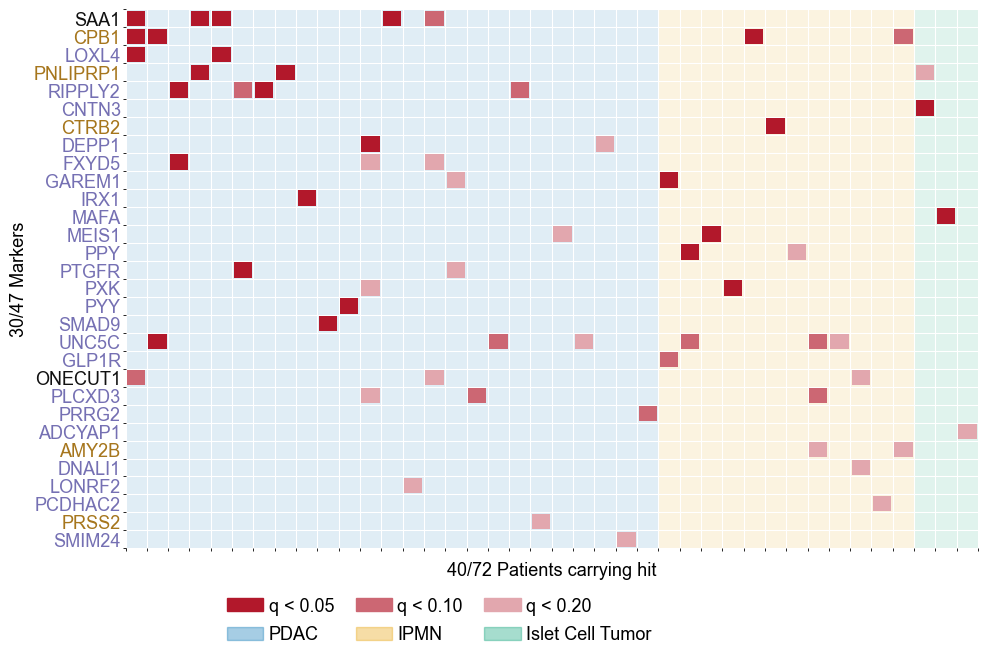

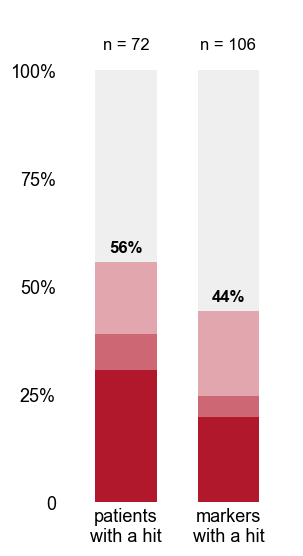

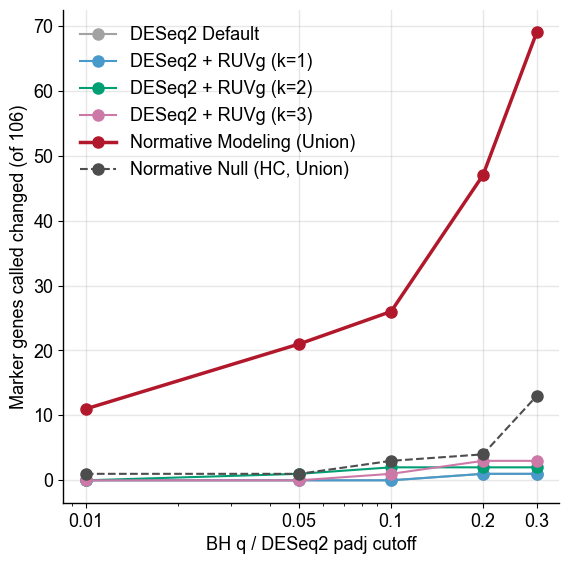

In [212]:
SET_C = {'acinar': '#A6761D', 'islet': '#7570B3', 'ductal': '#111111'}
Q_TIERS = [0.05, 0.10, 0.20]
Q_GRID = [0.01, 0.05, 0.10, 0.20, 0.30]
TOP_ROWS = 30  # row cap: more markers get a hit than fit as readable labels
STAGE_C = {'PDAC': '#0072B2', 'IPMN': '#E69F00', 'Islet Cell Tumor': '#009E73'}
BAR_W, BAR_GAP = 0.9, 1.5 
LABELS = {
    'grid_x': '{n_pat_hit}/{n_pat} Patients carrying hit',
    'grid_y': '{n_rows}/{n_markers_hit} Markers',
    'bar_x': ('patients\nwith a hit', 'markers\nwith a hit'),
    'bar_n': 'n = {n}',
    'sweep_x': 'BH q / DESeq2 padj cutoff',
    'sweep_y': '{ylab} (of {n_panel})',
}


def marker_recovery_fig(mtbl, fname, ylab, color='#B2182B', row_colors=None,
                        detected_only=False, nz=None, labels=None):
    lab_of = {**LABELS, **(labels or {})}
    cols = np.array([gpos[e] for e in mtbl['ens']])
    sig_q = {q: bh_sig_matrix(Z_neo, q=q)[:, cols] for q in sorted(set(Q_TIERS + Q_GRID))}
    sig_hc_q = {q: bh_sig_matrix(Z_hc_qc, q=q)[:, cols] for q in Q_GRID}
    use = mtbl['detected'].values if detected_only else np.ones(len(mtbl), bool)
    tier = np.zeros(sig_q[Q_TIERS[0]].shape)
    for i, q in enumerate(sorted(Q_TIERS, reverse=True)):
        tier[sig_q[q]] = i + 1
    tier[:, ~use] = 0

    # three separate figures, saved as <stem>_grid / _bars / _sweep
    stem = Path(fname).stem
    fig_grid, ax = plt.subplots(figsize=(11.0, 7.0))
    hit = tier > 0
    cand = list(np.where(hit.any(axis=0))[0])
    rows, shown = [], np.zeros(tier.shape[0], bool)
    while cand and len(rows) < TOP_ROWS:
        gain = [(int((hit[:, c] & ~shown).sum()), int(tier[:, c].max()), int(hit[:, c].sum()))
                for c in cand]
        if max(g[0] for g in gain) == 0:
            shown[:] = False
            continue
        best = cand[max(range(len(cand)), key=lambda i: gain[i])]
        rows.append(best)
        shown |= hit[:, best]
        cand.remove(best)
    rows = np.array(rows)
    rows = rows[np.lexsort((mtbl['symbol'].values[rows], -tier[:, rows].max(axis=0),
                            -(tier[:, rows] == len(Q_TIERS)).sum(axis=0)))]
    keep = np.where(tier.max(axis=1) > 0)[0]
    keep = keep[np.lexsort((-(tier[np.ix_(keep, rows)] == len(Q_TIERS)).sum(axis=1),
                            [list(STAGE_C).index(s) for s in stage_neo[keep]]))]
    T = tier[np.ix_(keep, rows)].T
    ax.imshow(np.zeros(T.shape), cmap='Greys', vmin=0, vmax=1, aspect='auto')
    shades = [mcolors.to_hex(1 - w + w * np.array(mcolors.to_rgb(color))) for w in (1.0, 0.66, 0.38)]
    tier_h = []
    for lvl, sh in zip(range(len(Q_TIERS), 0, -1), shades):
        for y, x in zip(*np.where(T == lvl)):
            ax.add_patch(plt.Rectangle((x - 0.43, y - 0.43), 0.86, 0.86, color=sh, lw=0, zorder=2))
        tier_h.append(plt.Rectangle((0, 0), 1, 1, color=sh))
    # a patch in data coords, not axvspan: axvspan spans the whole axes and spills past the
    # first and last gridline by half a line width
    for j, sm in enumerate(stage_neo[keep]):
        ax.add_patch(plt.Rectangle((j - 0.5, -0.5), 1, len(rows), color=STAGE_C[sm],
                                   alpha=0.12, lw=0, zorder=0))
    ax.set_xlim(-0.5, len(keep) - 0.5)
    ax.set_ylim(len(rows) - 0.5, -0.5)
    ax.set_xticks(np.arange(-0.5, len(keep), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(rows), 1), minor=True)
    ax.grid(which='minor', color='#FFFFFF', lw=0.8)
    ax.set_yticks(range(len(rows)), [mtbl['symbol'].values[r] for r in rows])
    if row_colors is not None:
        for t, r in zip(ax.get_yticklabels(), rows):
            t.set_color(row_colors[r])
    ax.set_xticks([])
    ax.set_xlabel(lab_of['grid_x'].format(n_pat_hit=len(keep), n_pat=tier.shape[0]))
    ax.set_ylabel(lab_of['grid_y'].format(n_rows=len(rows),
                                          n_markers_hit=int((tier.max(axis=0) > 0).sum())))
    ax.tick_params(length=0)
    h2 = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.35) for c in STAGE_C.values()]
    l1 = [f'q < {q:.2f}' for q in sorted(Q_TIERS)]
    hh = [x for pair in zip(tier_h, h2) for x in pair]
    ll = [x for pair in zip(l1, STAGE_C) for x in pair]
    ax.legend(hh, ll, frameon=False, loc='upper left', bbox_to_anchor=(0.1, -0.06), ncol=3,
              handletextpad=0.3, columnspacing=1.2, labelspacing=0.6)
    for sp in ax.spines.values():
        sp.set_visible(False)

    # middle: the two grid margins as fractions, stacked by the q that earned them
    fig_grid.savefig(FIG / f'{stem}_grid.png', dpi=300, bbox_inches='tight')

    fig_bar, ax = plt.subplots(figsize=(3, 6.4))
    pat_f = [(sig_q[q][:, use].sum(axis=1) > 0).mean() for q in sorted(Q_TIERS)]
    mrk_f = [(sig_q[q][:, use].sum(axis=0) > 0).mean() for q in sorted(Q_TIERS)]
    xs = [0, BAR_GAP]
    for x, (fr, n) in zip(xs, zip([pat_f, mrk_f], [tier.shape[0], int(use.sum())])):
        bot = 0
        for seg, sh in zip([fr[0], fr[1] - fr[0], fr[2] - fr[1]], shades):
            ax.bar(x, seg, bottom=bot, width=BAR_W, color=sh, lw=0)
            bot += seg
        ax.bar(x, 1 - bot, bottom=bot, width=BAR_W, color='#EFEFEF', lw=0)
        ax.text(x, bot + 0.015, f'{bot:.0%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax.text(x, 1.04, lab_of['bar_n'].format(n=n), ha='center', va='bottom', fontsize=12)
    ax.set_xlim(-0.5 - BAR_W / 2, BAR_GAP + 0.5 + BAR_W / 2)
    ax.set_xticks(xs, list(lab_of['bar_x']))
    ax.set_ylim(0, 1.14)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ['0', '25%', '50%', '75%', '100%'])
    ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)

    # HC noise floor: the same union rule on the batch-matched healthy samples. There are fewer
    # of them than patients, so a size-matched random draw is the whole set -- nothing to resample.
    hc_union = {q: int(sig_hc_q[q][:, use].any(axis=0).sum()) for q in Q_GRID}
    ens = mtbl['ens'].values[use]
    fig_bar.savefig(FIG / f'{stem}_bars.png', dpi=300, bbox_inches='tight')

    fig_sweep, ax = plt.subplots(figsize=(6.4, 6.4))
    for design, c in zip(['no_covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3'],
                         ['#A2A2A2', '#489ACA', '#009E73', '#CC79A7']):
        lab = {'no_covariate': 'DESeq2 Default'}.get(design, f"DESeq2 + RUVg (k={design[-1]})")
        pj = padj_of[('PancreaticNeoplasm', design)]['padj'].reindex(ens).fillna(1.0).values
        ax.plot(Q_GRID, [(pj < q).sum() for q in Q_GRID], 'o-', color=c, label=lab, markersize=8, lw=1.5)
    nm = [int((sig_q[q][:, use].sum(axis=0) > 0).sum()) for q in Q_GRID]
    ax.plot(Q_GRID, nm, 'o-', color=color, lw=2.5, label='Normative Modeling (Union)', markersize=8)
    ax.plot(Q_GRID, [hc_union[q] for q in Q_GRID], 'o--', color='#4D4D4D', lw=1.5, markersize=8,
            label='Normative Null (HC, Union)')
    ax.set_xscale('log')
    ax.set_xticks(Q_GRID, [str(q) for q in Q_GRID])
    ax.set_xlabel(lab_of['sweep_x'])
    ax.set_ylabel(lab_of['sweep_y'].format(ylab=ylab, n_panel=len(ens)))
    ax.grid(zorder=0, alpha=0.3)
    ax.legend(frameon=False, loc='upper left')
    fig_sweep.savefig(FIG / f'{stem}_sweep.png', dpi=300, bbox_inches='tight')

    if nz is not None:
        for q in Q_GRID:
            h = sig_q[q]
            print(f'q<{q}: {int(h.sum())} sample-level hits, '
                  f'{int((h & nz).sum())} with a nonzero raw count in that sample')
    print(f'grid: {len(rows)} markers x {len(keep)} patients; '
          f'q<0.05 tiles drawn {int((T == len(Q_TIERS)).sum())} of {int(sig_q[0.05][:, use].sum())}')
    out = pd.DataFrame({'cutoff': Q_GRID, 'markers': nm,
                        'patients': [int((sig_q[q][:, use].sum(axis=1) > 0).sum()) for q in Q_GRID],
                        'hc_markers': [hc_union[q] for q in Q_GRID],
                        **{d: [int((padj_of[('PancreaticNeoplasm', d)]['padj'].reindex(ens)
                                    .fillna(1.0).values < q).sum()) for q in Q_GRID]
                           for d in ['no_covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3']}})
    print(out.to_string(index=False))
    return out


panglao_recovery = marker_recovery_fig(
    marker_tbl, 'fig_marker_recovery.png', 'Marker genes called changed',
    color='#B2182B', row_colors=marker_tbl['set'].map(SET_C).values, nz=cnt[is_pat] > 0)
panglao_recovery.to_csv(OUT / 'marker_recovery_by_cutoff.csv', index=False)


OT 'exocrine pancreatic carcinoma' (MONDO_0005192): 500 symbols -> 500 genes, 458 at detect_frac >= 0.1
q<0.01: 57 sample-level hits, 34 with a nonzero raw count in that sample
q<0.05: 150 sample-level hits, 89 with a nonzero raw count in that sample
q<0.1: 240 sample-level hits, 139 with a nonzero raw count in that sample
q<0.2: 487 sample-level hits, 297 with a nonzero raw count in that sample
q<0.3: 799 sample-level hits, 517 with a nonzero raw count in that sample
grid: 30 markers x 44 patients; q<0.05 tiles drawn 38 of 131
 cutoff  markers  patients  hc_markers  no_covariate  ruvg_k1  ruvg_k2  ruvg_k3
   0.01       41        16           1             0        1        0        0
   0.05      107        26          13             0        2        1        2
   0.10      162        35          30             0        4        5        2
   0.20      272        44          63             2        8       11        8
   0.30      348        54         135             4       13     

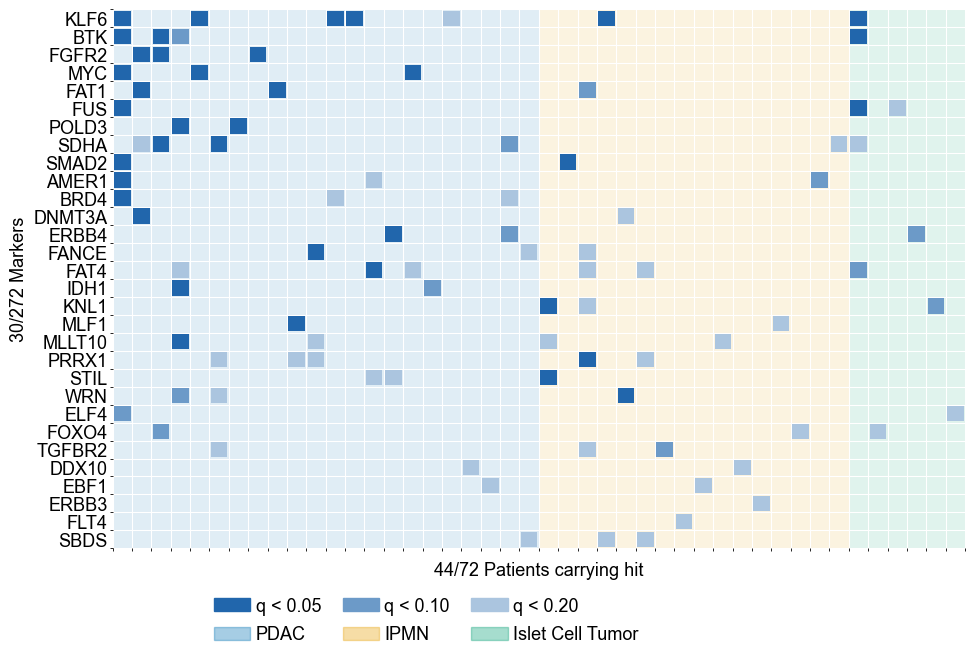

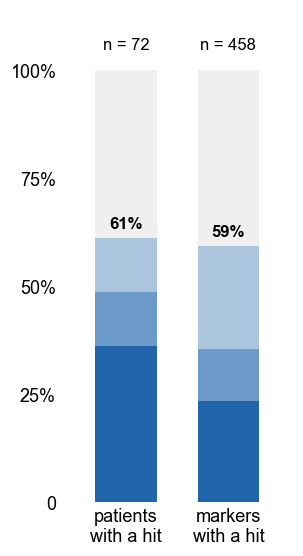

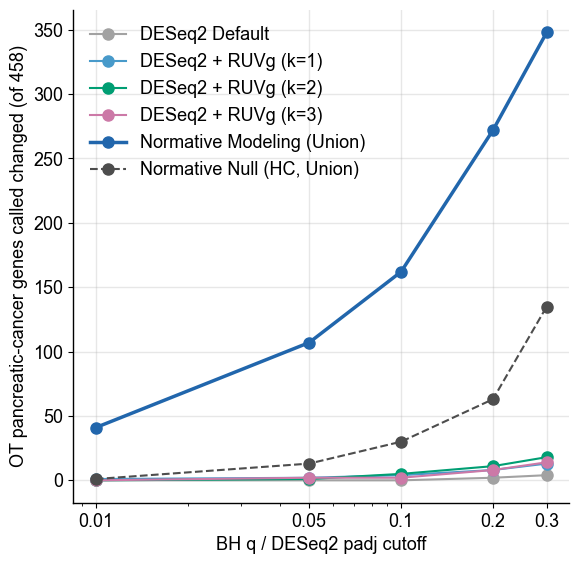

In [213]:
# Same figure on the other kind of panel: Open Targets association genes for pancreatic cancer
# (notebook 4's disease-marker recipe), which are risk/association genes rather than cell-type
# markers. 500 genes is noise-prone at RQR, so this one is restricted to the detected panel.
OT_REF = config.DISEASE_REF_DIR / 'Pancreatic Cancer.json'
OT_TOPN = 500
OT_SCORE_FLOOR = 0.01

ot = json.load(open(OT_REF))
ot_scores = dict(ot['genes'])
ot_syms = set([g for g, s in sorted(ot['genes'], key=lambda gs: -gs[1])
               if s >= OT_SCORE_FLOOR][:OT_TOPN])
sym_g = np.array([sym_of.get(g, g.split('.')[0]) for g in genes])
ot_idx = np.where(np.isin(sym_g, list(ot_syms)))[0]
ot_tbl = pd.DataFrame(dict(ens=genes[ot_idx], symbol=sym_g[ot_idx],
                           score=[ot_scores.get(s, 0.0) for s in sym_g[ot_idx]]))
ot_cnt, _ = raw_counts(np.concatenate([names_neo, names_hc]), ot_tbl['ens'].tolist())
ot_tbl['detect_frac'] = (ot_cnt > 0).mean(axis=0)
ot_tbl['detected'] = ot_tbl['detect_frac'] >= MARKER_MIN_DETECT
ot_tbl.to_csv(OUT / 'ot_marker_panel.csv', index=False)
print(f"OT '{ot['ot_disease']}' ({ot['efo']}): {len(ot_syms)} symbols -> {len(ot_tbl)} genes, "
      f"{int(ot_tbl['detected'].sum())} at detect_frac >= {MARKER_MIN_DETECT}")

ot_recovery = marker_recovery_fig(
    ot_tbl, 'fig_marker_recovery_opentargets.png', 'OT pancreatic-cancer genes called changed',
    color='#2166AC', detected_only=True, nz=ot_cnt[:len(names_neo)] > 0)
ot_recovery.to_csv(OUT / 'ot_marker_recovery_by_cutoff.csv', index=False)


In [ ]:
# The whole q-tier set in one place, rotated: markers on x, patients on y. The panel is large
# enough that the 30-row summary above hides most of it, so this one has no row cap and splits
# the markers into GRID_BLOCKS stacked strips.
GRID_BLOCKS = 4
CELL_W, CELL_H = 0.26, 0.14  # inches per marker column / patient row
LABEL_IN = 1.5               # inches reserved under each strip for the rotated gene names


def marker_grid_full(mtbl, fname, color='#B2182B', blocks=GRID_BLOCKS, detected_only=True,
                     labels=None):
    lab_of = {**LABELS, **(labels or {})}
    cols = np.array([gpos[e] for e in mtbl['ens']])
    use = mtbl['detected'].values if detected_only else np.ones(len(mtbl), bool)
    sig_q = {q: bh_sig_matrix(Z_neo, q=q)[:, cols] & use[None, :] for q in Q_TIERS}
    tier = np.zeros(sig_q[Q_TIERS[0]].shape)
    for i, q in enumerate(sorted(Q_TIERS, reverse=True)):
        tier[sig_q[q]] = i + 1

    mk = np.where(tier.max(axis=0) > 0)[0]
    mk = mk[np.lexsort((mtbl['symbol'].values[mk], -(tier[:, mk] > 0).sum(axis=0),
                        -tier[:, mk].max(axis=0)))]
    pt = np.where(tier[:, mk].max(axis=1) > 0)[0]
    pt = pt[np.lexsort((-(tier[np.ix_(pt, mk)] == len(Q_TIERS)).sum(axis=1),
                        [list(STAGE_C).index(s) for s in stage_neo[pt]]))]
    chunks = np.array_split(mk, blocks)
    shades = [mcolors.to_hex(1 - w + w * np.array(mcolors.to_rgb(color))) for w in (1.0, 0.66, 0.38)]

    grid_in = CELL_H * len(pt)
    fig, axes = plt.subplots(blocks, 1, figsize=(CELL_W * max(map(len, chunks)) + 1.0,
                                                 blocks * (grid_in + LABEL_IN)),
                             gridspec_kw=dict(hspace=LABEL_IN / grid_in))
    for ax, ch in zip(np.atleast_1d(axes), chunks):
        T = tier[np.ix_(pt, ch)]
        ax.imshow(np.zeros(T.shape), cmap='Greys', vmin=0, vmax=1, aspect='auto')
        for lvl, sh in zip(range(len(Q_TIERS), 0, -1), shades):
            for y, x in zip(*np.where(T == lvl)):
                ax.add_patch(plt.Rectangle((x - 0.43, y - 0.43), 0.86, 0.86, color=sh, lw=0,
                                           zorder=2))
        for i, sm in enumerate(stage_neo[pt]):
            ax.add_patch(plt.Rectangle((-0.5, i - 0.5), len(ch), 1, color=STAGE_C[sm],
                                       alpha=0.12, lw=0, zorder=0))
        ax.set_xlim(-0.5, len(ch) - 0.5)
        ax.set_ylim(len(pt) - 0.5, -0.5)
        ax.set_xticks(np.arange(-0.5, len(ch), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(pt), 1), minor=True)
        ax.grid(which='minor', color='#FFFFFF', lw=0.8)
        ax.set_xticks(range(len(ch)), mtbl['symbol'].values[ch], rotation=90)
        ax.set_yticks([])
        ax.set_ylabel(lab_of['grid_full_y'].format(n_pat_hit=len(pt)))
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(False)
    # legend fills column-major, so interleave to put the q tiers on the top row and the
    # subtypes under them
    h1 = [plt.Rectangle((0, 0), 1, 1, color=sh) for sh in shades]
    h2 = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.35) for c in STAGE_C.values()]
    h = [x for pair in zip(h1, h2) for x in pair]
    l = [x for pair in zip([f'q < {q:.2f}' for q in sorted(Q_TIERS)], STAGE_C)
         for x in pair]
    np.atleast_1d(axes)[-1].legend(h, l, frameon=False, loc='upper left',
                                   bbox_to_anchor=(0.35, -LABEL_IN / grid_in), ncol=3,
                                   handletextpad=0.3, columnspacing=1.2)
    np.atleast_1d(axes)[-1].set_xlabel(lab_of['grid_full_x'].format(
        n_markers=len(mk), n_pat_hit=len(pt), n_pat=len(stage_neo)))
    fig.savefig(FIG / fname, dpi=300, bbox_inches='tight')
    counts = {q: int(sig_q[q].any(axis=0).sum()) for q in sorted(Q_TIERS)}
    print(f'{fname}: {len(mk)} markers x {len(pt)} patients; markers by cutoff {counts}')
    return mtbl.iloc[mk].assign(**{f'n_pat_q{q:g}': sig_q[q][:, mk].sum(axis=0) for q in Q_TIERS})

LABELS['grid_full_x'] = ('every marker called at q < 0.20: {n_markers} genes '
                         'in {n_pat_hit} of {n_pat} patients')
LABELS['grid_full_y'] = '{n_pat_hit} patients'
ot_grid = marker_grid_full(ot_tbl, 'fig_ot_marker_grid_tiers.png', color='#2166AC')
ot_grid.to_csv(OUT / 'ot_marker_grid_tiers.csv', index=False)
